<a href="https://colab.research.google.com/github/maniratnam256/ai-mentor-portfolio/blob/main/Day7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q chromadb sentence-transformers scikit-learn matplotlib

from sentence_transformers import SentenceTransformer
from chromadb import PersistentClient

# Free, local, 384-dim embeddings
embed = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
print('Embedding dim:', embed.get_sentence_embedding_dimension())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the s

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding dim: 384


/tmp/ipykernel_1328/1158961417.py:8: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print('Embedding dim:', embed.get_sentence_embedding_dimension())


In [ ]:
with open('../lib/syllabi/cse_sem5.txt') as f:
    text = f.read()

# Split on blank lines into paragraphs
paragraphs = [p.strip() for p in text.split('\n\n') if p.strip()][:10]

print(f'Loaded {len(paragraphs)} paragraphs')
for i, p in enumerate(paragraphs):
    print(f'  [{i+1}] {p[:80]}')

Loaded 7 paragraphs
  [1] CSE Semester 5 — Syllabus Excerpt
  [2] Operating Systems:
Process management, threads, scheduling algorithms (FCFS, SJF
  [3] Database Management Systems:
ER model, relational model, normalisation (1NF thro
  [4] Computer Networks:
OSI and TCP/IP models. Physical, data link, network, transpor
  [5] Software Engineering:
SDLC models: waterfall, agile, scrum.
Requirements enginee
  [6] Theory of Computation:
Finite automata (DFA, NFA), regular expressions, regular 
  [7] Lab work:
OS lab: implement scheduling algorithms in C.
DBMS lab: build a hospit


In [ ]:
client = PersistentClient(path='./chroma_db')
col = client.get_or_create_collection('hello_syllabus')

# Embed all 10 paragraphs
vectors = embed.encode(paragraphs).tolist()

# Add to collection (with sequential IDs)
col.add(
    documents=paragraphs,
    embeddings=vectors,
    ids=[f'p{i}' for i in range(len(paragraphs))]
)

print(f'Indexed {col.count()} documents')

Indexed 7 documents


In [ ]:
queries = [
    'what is dynamic programming?',
    'machine learning topics',
    'operating system processes',
]

for q in queries:
    print(f'\nQuery: {q}')
    qv = embed.encode([q]).tolist()
    results = col.query(query_embeddings=qv, n_results=3)
    docs = results['documents'][0]
    distances = results['distances'][0]
    for j, (d, dist) in enumerate(zip(docs, distances)):
        print(f'  [{j+1}] (dist={dist:.3f}) {d[:80]}')


Query: what is dynamic programming?
  [1] (dist=1.464) Theory of Computation:
Finite automata (DFA, NFA), regular expressions, regular 
  [2] (dist=1.469) Lab work:
OS lab: implement scheduling algorithms in C.
DBMS lab: build a hospit
  [3] (dist=1.476) Operating Systems:
Process management, threads, scheduling algorithms (FCFS, SJF

Query: machine learning topics
  [1] (dist=1.300) Theory of Computation:
Finite automata (DFA, NFA), regular expressions, regular 
  [2] (dist=1.526) Lab work:
OS lab: implement scheduling algorithms in C.
DBMS lab: build a hospit
  [3] (dist=1.533) Operating Systems:
Process management, threads, scheduling algorithms (FCFS, SJF

Query: operating system processes
  [1] (dist=0.713) Operating Systems:
Process management, threads, scheduling algorithms (FCFS, SJF
  [2] (dist=1.246) Database Management Systems:
ER model, relational model, normalisation (1NF thro
  [3] (dist=1.370) Lab work:
OS lab: implement scheduling algorithms in C.
DBMS lab: build a hos

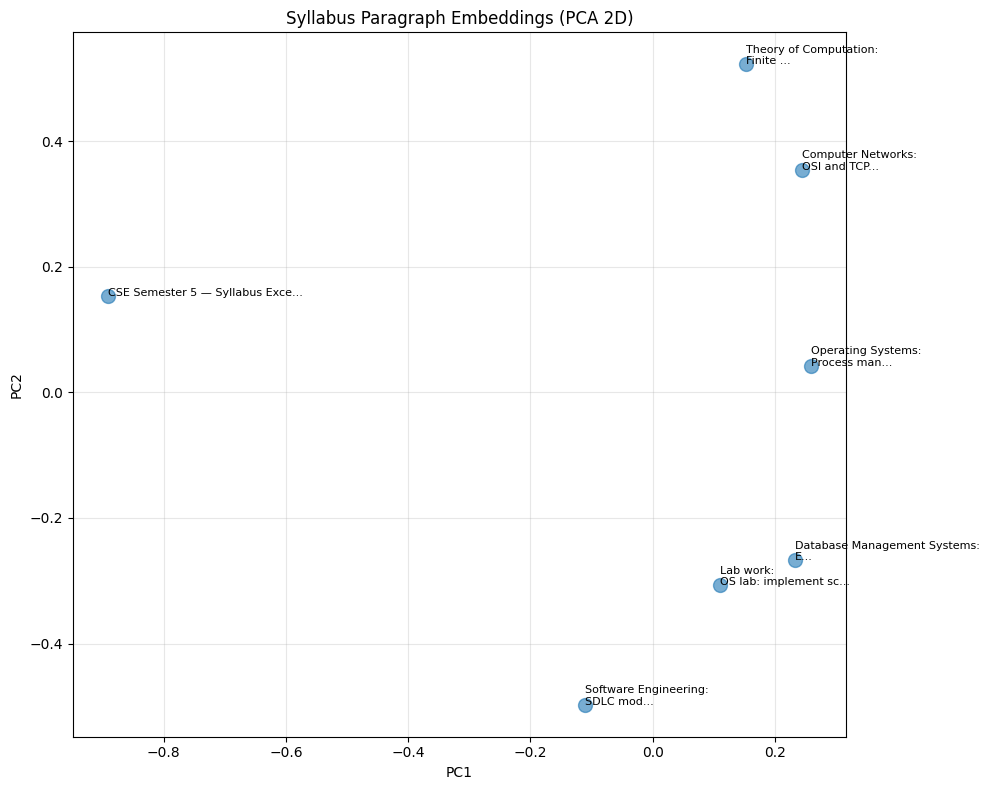

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

vectors_arr = np.array(vectors)

pca = PCA(n_components=2)
xy = pca.fit_transform(vectors_arr)

plt.figure(figsize=(10, 8))
plt.scatter(xy[:, 0], xy[:, 1], s=100, alpha=0.6)
for i, p in enumerate(paragraphs):
    label = p[:30] + '...' if len(p) > 30 else p
    plt.annotate(label, (xy[i, 0], xy[i, 1]), fontsize=8)
plt.title('Syllabus Paragraph Embeddings (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

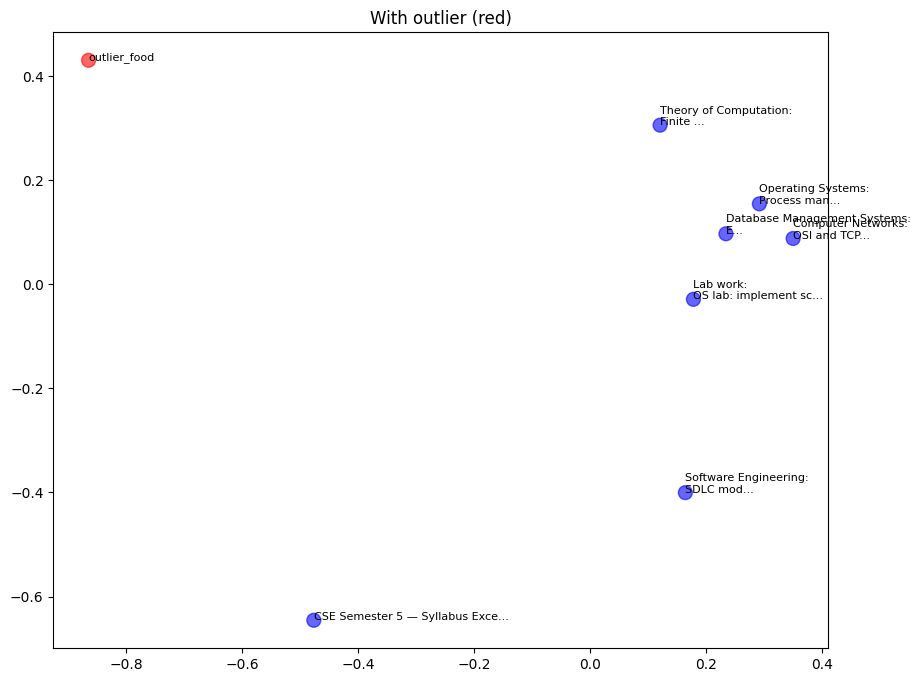

In [ ]:
outlier = "Today's special at the cafeteria is butter chicken with rice and naan."

col.add(
    documents=[outlier],
    embeddings=embed.encode([outlier]).tolist(),
    ids=['outlier_food']
)

# Re-fetch all and re-plot
all_docs = col.get(include=['embeddings', 'documents'])
all_vecs = np.array(all_docs['embeddings'])
labels = all_docs['ids']

pca = PCA(n_components=2) # Re-initialize PCA to ensure it fits the new data
xy = pca.fit_transform(all_vecs)
plt.figure(figsize=(10, 8))
colors = ['red' if 'outlier' in l else 'blue' for l in labels]
plt.scatter(xy[:, 0], xy[:, 1], c=colors, s=100, alpha=0.6)
for i, l in enumerate(labels):
    short = labels[i] if 'outlier' in labels[i] else all_docs['documents'][i][:30] + '...'
    plt.annotate(short, (xy[i, 0], xy[i, 1]), fontsize=8)
plt.title('With outlier (red)')
plt.show()

In [ ]:
!pip install -q chromadb sentence-transformers langchain langchain-google-genai langchain-community langchain-chroma langchain-huggingface pypdf

from sentence_transformers import SentenceTransformer
from chromadb import PersistentClient
import json, pathlib, os

embed = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
client = PersistentClient(path='./chroma_db')

# Use a fresh collection for the capstone (different from morning's hello_syllabus)
col = client.get_or_create_collection('placement_kb')
print(f'Starting count: {col.count()}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.8/343.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
google-adk 1.29.0 requires opentelemetry-api<1.39.0,>=1.36.0, but you have opentelemetry-api 1.42.1 which is incompatible.
google-adk 1.29.0 requires opentelemetry-sdk<1.39.0,>=1.36.0, but you have opentelemetry-sdk 1.42.1 which is incompatible.
openteleme

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Starting count: 0


In [ ]:
# Upgrade langchain and langchain-community to ensure all components are present
!pip install --upgrade langchain langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.3/114.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.3/235.3 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.2/56.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.3 MB/s eta 0:00:00
  Attempting uninstall: langgraph-checkpoint
    Found existing installation: langgraph-checkpoint 4.0.2
    Uninstalling langgraph-checkpoint-4.0.2:
      Successfully uninstalled langgraph-checkpoint-4.0.2
  Attempting uninstall: langgraph-prebuilt
    Found existing installation: langgraph-prebuilt 1.0.10
    Uninstalling langgraph-prebuilt-1.0.10:
      Successfully uninstalled langgraph-prebuilt-1.0.10
  Attempting uninstall: langgraph
    Found existing installation: langgraph 1.1.9
    Uninstalling langgraph-1.1.9:
      Successfully uninstalled langgraph-1.1.9
  Attempting uninstall: langchain
    Found existing installation: langchain 1.2.15
    Uninstalling langcha

In [ ]:
# Combine cached JDs (from kit) with own JDs (from Day 6)
all_jds = []

# Cached
for line in pathlib.Path('../lib/syllabi/jds.jsonl').read_text().splitlines():
    all_jds.append(json.loads(line))

# Own (if exists from Day 6)
own = pathlib.Path('data/jds.jsonl')
if own.exists():
    for line in own.read_text().splitlines():
        all_jds.append(json.loads(line))

print(f'Total JDs: {len(all_jds)}')

# Index each JD as one document
for i, jd in enumerate(all_jds):
    text = (
        f"{jd['company']} - {jd['role']}: "
        f"must-haves: {', '.join(jd['must_have_skills'])}. "
        f"nice-to-haves: {', '.join(jd.get('nice_to_have_skills', []))}. "
        f"min CGPA: {jd.get('min_cgpa', 'N/A')}. "
        f"locations: {', '.join(jd.get('locations', []))}. "
        f"package: {jd.get('package_lpa', 'N/A')} LPA."
    )
    col.add(
        documents=[text],
        embeddings=embed.encode([text]).tolist(),
        ids=[f'jd_{i}'],
        metadatas=[{
            'type': 'jd',
            'company': jd['company'],
            'min_cgpa': float(jd.get('min_cgpa') or 0),
            'package_lpa': float(jd.get('package_lpa') or 0),
        }]
    )

print(f'Indexed {col.count()} JD documents')

Total JDs: 10
Indexed 10 JD documents


In [ ]:
# Install required packages
!pip install -q langchain langchain-text-splitters

# Imports
import pathlib
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Create text splitter
splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
    separators=["\n\n", "\n", ". ", " "]
)

# Adjust path if needed
syllabi_dir = pathlib.Path("../lib/syllabi")

# Verify folder exists
print("Looking in:", syllabi_dir.resolve())

if not syllabi_dir.exists():
    raise FileNotFoundError(
        f"Syllabus folder not found: {syllabi_dir}"
    )

chunk_count = 0

# Process all .txt files
for syllabus_path in syllabi_dir.glob("*.txt"):

    print(f"Processing {syllabus_path.name}")

    text = syllabus_path.read_text(encoding="utf-8")

    chunks = splitter.split_text(text)

    for j, chunk in enumerate(chunks):

        col.add(
            documents=[chunk],
            embeddings=embed.encode([chunk]).tolist(),
            ids=[f"{syllabus_path.stem}_{j}"],
            metadatas=[{
                "type": "syllabus",
                "source": syllabus_path.stem,
                "chunk_index": j
            }]
        )

        chunk_count += 1

print(f"\nIndexed {chunk_count} syllabus chunks")
print(f"Total docs in placement_kb: {col.count()}")

Looking in: /usr/lib/syllabi
Processing mech_sem5.txt
Processing eee_sem5.txt
Processing cse_sem5.txt
Processing ece_sem5.txt
Processing cse_sem6.txt

Indexed 15 syllabus chunks
Total docs in placement_kb: 25


In [ ]:
pip install --upgrade langchain langchain-community

In [ ]:
!pip install -q -U langchain-core langchain-chroma langchain-huggingface langchain-google-genai chromadb sentence-transformers

import os, getpass
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

if "GEMINI_API_KEY" not in os.environ:
    os.environ["GEMINI_API_KEY"] = getpass.getpass("Enter Gemini API key: ")

emb_lc = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

vs = Chroma(
    collection_name="placement_kb",
    embedding_function=emb_lc,
    persist_directory="./chroma_db"
)

retriever = vs.as_retriever(search_kwargs={"k": 4})

prompt = ChatPromptTemplate.from_template("""
Use ONLY the following context.

Cite chunk ids used.

If the answer is not found, say "I do not know".

Context:
{context}

Question:
{question}

Answer:
""")

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=os.environ["GEMINI_API_KEY"],
    temperature=0
)

def format_docs(docs):
    return "\n\n".join(
        f"Chunk ID: {doc.metadata.get('id', doc.metadata.get('source', 'unknown'))}\n{doc.page_content}"
        for doc in docs
    )

qa = (
    {
        "context": retriever | format_docs,
        "question": RunnablePassthrough()
    }
    | prompt
    | llm
    | StrOutputParser()
)

print("QA chain ready.")

# Test
question = "What is placement training?"
answer = qa.invoke(question)
print(answer)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.9/588.9 kB 7.7 MB/s eta 0:00:00
Enter Gemini API key: ··········


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


QA chain ready.
I do not know.


In [ ]:
questions = [
    'Which companies want Java + DSA + CGPA 7+?',
    'What are the Sem 5 OS topics?',
    'Which JDs require Python?',
    'Top 3 skills appearing across all JDs?',
    'Companies hiring in Hyderabad?',
]

for q in questions:
    answer = qa.invoke(q)

    print(f'\nQ: {q}')
    print(f'A: {answer}')


Q: Which companies want Java + DSA + CGPA 7+?
A: The companies that want Java + DSA + CGPA 7+ are:

*   TCS Digital - Software Engineer (Chunk ID: unknown)
*   Goldman Sachs - Technology Analyst (Chunk ID: unknown)

Q: What are the Sem 5 OS topics?
A: The Sem 5 OS topics include:
Process management, threads, scheduling algorithms (FCFS, SJF, Round Robin, Priority).
Memory management: paging, segmentation, virtual memory, page replacement.
File systems: directory structures, file allocation methods.
Synchronisation: critical section, semaphores, monitors, classical problems.
Deadlocks: prevention, avoidance (Banker's algorithm), detection, recovery. (cse_sem5)

Q: Which JDs require Python?
A: The JDs that require Python are:
*   Cognizant - Programmer Analyst (Chunk ID: unknown)
*   Goldman Sachs - Technology Analyst (Chunk ID: unknown)
*   Accenture - Associate Software Engineer (Chunk ID: unknown)

Q: Top 3 skills appearing across all JDs?
A: The top 3 skills appearing across all JDs

In [ ]:
!pip uninstall -y ragas langchain-google-vertexai
!pip install -q ragas[google] datasets --upgrade
!pip install -q langchain-google-vertexai


Found existing installation: ragas 0.4.3
Uninstalling ragas-0.4.3:
  Successfully uninstalled ragas-0.4.3
Found existing installation: langchain-google-vertexai 3.2.3
Uninstalling langchain-google-vertexai-3.2.3:
  Successfully uninstalled langchain-google-vertexai-3.2.3


In [ ]:
import json, pathlib
from datasets import Dataset

testset_path = pathlib.Path('./sample_data/ragas_testset_20.jsonl')
testset = [json.loads(line) for line in testset_path.read_text().splitlines()]
print(f'Loaded {len(testset)} test questions')

# Inspect first 3
for i, t in enumerate(testset[:3]):
    print(f'\n[{i+1}] Q: {t["question"]}')
    print(f'    Reference: {t["reference"]}')

Loaded 20 test questions

[1] Q: Which companies want Java + DSA + CGPA 7+?
    Reference: TCS Digital, Goldman Sachs, Cognizant

[2] Q: What is the minimum CGPA for Amazon SDE Intern?
    Reference: 7.5

[3] Q: Which company has the highest LPA package?
    Reference: Amazon at 30 LPA


In [ ]:
# Reuse the qa chain from Day 7 morning (or re-instantiate from saved chroma_db)
# ... ensure 'qa' is available ...

eval_rows = []
for t in testset[:5]:
    result = qa.invoke({'query': t['question']})
    answer = result['result']
    contexts = [d.page_content for d in result['source_documents']]
    eval_rows.append({
        'question': t['question'],
        'contexts': contexts,
        'answer': answer,
        'reference': t['reference'],   # ground truth from testset
    })
    print(f'  ✓ {t["question"][:60]}')

print(f'\nCollected {len(eval_rows)} RAG outputs')

  ✓ Which companies want Java + DSA + CGPA 7+?
  ✓ What is the minimum CGPA for Amazon SDE Intern?
  ✓ Which company has the highest LPA package?
  ✓ List 3 companies hiring in Bangalore.
  ✓ What skills does Microsoft want?

Collected 5 RAG outputs


In [ ]:
pip install -q langchain-google-vertexai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.8/354.8 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.3/66.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 375.2/375.2 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.9/934.9 kB 34.9 MB/s eta 0:00:00


In [ ]:
from ragas import evaluate
from ragas.metrics import context_precision, faithfulness, answer_relevancy
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_huggingface import HuggingFaceEmbeddings

# RAGAS uses a judge LLM under the hood. Use Gemini.
judge_llm = LangchainLLMWrapper(ChatGoogleGenerativeAI(model='gemini-2.5-flash'))
judge_emb = LangchainEmbeddingsWrapper(HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2'))

ds = Dataset.from_list(eval_rows)

result = evaluate(
    ds,
    metrics=[context_precision, faithfulness, answer_relevancy],
    llm=judge_llm,
    embeddings=judge_emb,
)
print(result)

ModuleNotFoundError: No module named 'langchain_community.chat_models.vertexai'

In [ ]:
import pkg_resources

print(f"ragas version: {pkg_resources.get_distribution('ragas').version}")
print(f"langchain version: {pkg_resources.get_distribution('langchain').version}")
print(f"langchain-community version: {pkg_resources.get_distribution('langchain-community').version}")
try:
    print(f"langchain-google-vertexai version: {pkg_resources.get_distribution('langchain-google-vertexai').version}")
except pkg_resources.DistributionNotFound:
    print("langchain-google-vertexai not found or installed incorrectly.")


ragas version: 0.4.3
langchain version: 1.3.1
langchain-community version: 0.4.2
langchain-google-vertexai version: 3.2.3


/tmp/ipykernel_15604/4189272644.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
